# Differential accessibility between WT and KD within celltypes

In [4]:
here::i_am("rna_atac/dimensionality_reduction/WNN_MOFA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ArchR))
suppressPackageStartupMessages(library(edgeR))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [5]:
args = list()
# RNA seurat 
args$rna_seurat = file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/seurat_object.rds')
args$logFC_thr = 0.25
args$FDR_thr = 0.05
opts$min_cdr = 0.15
opts$groups = c('eomes_ko', 'wt')

args$groupA = 'wt'
args$groupB = 'eomes_ko'
opts$groups = c(args$groupA, args$groupB)
args$celltypes = unique(opts$clusters2celltypes)[unique(opts$clusters2celltypes) != 'blood']

cluster_levels = unique(opts$clusters2celltypes)

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/accessibility/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
plot_enr_heatmap = function(enrichMotifs, ntop=25) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)

    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] %>% .[,TF:=strsplit(TF, '_') %>% map_chr(1)]

    keep_tfs = enriched.dt %>% .[,variable:=factor(variable, levels=cluster_levels)] %>% .[order(variable)] %>% .[, head(.SD, ntop),  by=variable] %>% .$TF   
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        #.[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
         .[,TF:=factor(TF, levels=unique(keep_tfs))] %>%
        .[,variable:=factor(variable, levels=cluster_levels)]
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') +
    scale_fill_gradient(low='white', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') +
    theme_void() + theme(text=element_text(size=15), 
                         axis.text.x=element_text(angle=-90,hjust=0,vjust=0.5, size=15), 
                         axis.text.y=element_text(hjust=1),
                        legend.position='bottom')
p
    return(p)
}

In [77]:
volcano_plot = function(dt, ntop=5, logFC_thr = args$logFC_thr, FDR_thr = args$FDR_thr, title=NULL){
    tmp = dt[,sign:=ifelse(padj_fdr < FDR_thr & abs(logFC) > logFC_thr, ifelse(logFC>0, 'pos', 'neg'), 'nonsig')] %>%
        .[order(-abs(logFC))]
    labels = tmp[, head(.SD, ntop),  by=sign][sign!='nonsig']
    
    p = ggplot(tmp, aes(logFC, -log10(padj_fdr), col=sign)) + 
        geom_point() + 
        scale_colour_manual(values=c('pos' = 'red', 'neg' = 'blue', 'nonsig' = 'black')) + 
        geom_vline(xintercept=c(-logFC_thr, logFC_thr),  linetype = "longdash") +
        geom_vline(xintercept=0, color='orange', linetype = "longdash") +
        geom_hline(yintercept=-log10(FDR_thr),  linetype = "longdash") + 
        ggrepel::geom_text_repel(data=labels, aes(label=feature), 
                                 color='black',
                                 size=5,
                                 box.padding = 0.5, 
                                 max.overlaps = Inf,
                                 bg.color='white', 
                                 bg.r = 0.1) + 
        xlim(c(-max(abs(tmp$logFC)), max(abs(tmp$logFC)))) + 
        ggtitle(title) + 
        theme_bw() + 
        theme(text = element_text(size=15, color='black'),
             axis.text = element_text(size=15, color='black'),
             legend.position = 'none')

    
    return(p)
}

#### Load ArchR

In [5]:
# Load seurat for clusters & annotate celltypes
seurat = readRDS(args$rna_seurat)
seurat@meta.data$celltypes_v1 = opts$clusters2celltypes[match(as.character(seurat@meta.data$seurat_clusters), names(opts$clusters2celltypes))]

In [6]:
meta = as.data.table(seurat@meta.data, keep.rownames=T) %>% 
    setnames('rn', 'cell') %>% 
    .[day!='D3'] %>% # remove D3 cells
    .[,celltype_genotype:=paste0(celltypes_v1, '-', genotype)]

In [7]:
args$archr_directory = file.path(io$basedir, 'processed/atac/archR')
ArchRProject <- loadArchRProject(args$archr_directory)[meta$cell]

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [8]:
addArchRThreads(16)

Setting default number of Parallel threads to 16.



In [9]:
ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltypes_v1),
                                    cells = meta$cell,
                                    name = "celltype_v1",
                                    force=TRUE)

ArchRProject <- addCellColData(ArchRProj = ArchRProject, 
                                    data = as.character(meta$celltype_genotype),
                                    cells = meta$cell,
                                    name = "celltype_genotype",
                                    force=TRUE)


Overriding previous entry for celltype_genotype



In [10]:
# Get SingleCell object
atac.sce = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "PeakMatrix")

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-dc3e238916cd-Date-2023-02-26_Time-14-11-48.log
If there is an issue, please report to github with logFile!

2023-02-26 14:12:47 : Organizing colData, 0.984 mins elapsed.

2023-02-26 14:12:48 : Organizing rowData, 0.996 mins elapsed.

2023-02-26 14:12:48 : Organizing rowRanges, 0.996 mins elapsed.

2023-02-26 14:12:48 : Organizing Assays (1 of 1), 0.996 mins elapsed.

2023-02-26 14:13:43 : Constructing SummarizedExperiment, 1.916 mins elapsed.

2023-02-26 14:14:28 : Finished Matrix Creation, 2.67 mins elapsed.



In [11]:
atac.sce = atac.sce[,match(meta$cell, colnames(atac.sce))]
summary(colnames(atac.sce) == meta$cell)

   Mode    TRUE 
logical   28481 

In [12]:
atac.sce = as(atac.sce, 'SingleCellExperiment')

In [13]:
atac.sce@assays@data$counts = atac.sce@assays@data$PeakMatrix
atac.sce@assays@data$PeakMatrix = NULL

In [14]:
# Get peakSet and feature names
peakSet = as.data.table(ArchRProject@peakSet) %>% 
    .[, feature:=paste0(seqnames, ':', start, '-', end)] %>%
    .[,idx:=1:nrow(.)] %>%
    .[,c('feature', 'idx')]
features = peakSet$feature

rownames(atac.sce) = features
atac.sce$celltype = meta$celltypes_v1
atac.sce$genotype = meta$genotype

In [15]:
summary(colnames(atac.sce) == meta$cell)

   Mode    TRUE 
logical   28481 

### EdgeR Pseudobulk replicates

In [16]:
cell_metadata.dt = meta
cell_metadata.dt = cell_metadata.dt[,group:=paste0(celltypes_v1, '.', genotype)]

args$min_cells = 25
args$fraction_cells_per_replicate = 0.4
args$nrep = 5

# Define groups
opts$groups <- c(args$groupA,args$groupB)

In [17]:
##################################
## Create pseudobulk replicates ##
##################################

cell2replicate.dt <- lapply(unique(cell_metadata.dt$group), function(i){
  tmp <- cell_metadata.dt[group==i]
  if ((args$fraction_cells_per_replicate*nrow(tmp))<=args$min_cells) {
    ncells_per_replicate <- args$min_cells
  } else {
    ncells_per_replicate <- round(args$fraction_cells_per_replicate*nrow(tmp))
  }
  seq(1,args$nrep) %>% map(function(j) {
    tmp[sample.int(nrow(tmp),ncells_per_replicate)] %>% 
      .[,replicate:=sprintf("%s_rep%s",i,j)] %>%
      .[,c("cell","group","replicate")] %>% 
      return
  }) %>% rbindlist %>% return
}) %>% rbindlist

stats.dt <- cell2replicate.dt[,.(ncells=.N),c("group","replicate")]
print(stats.dt)

                          group                       replicate ncells
  1: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep1   2480
  2: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep2   2480
  3: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep3   2480
  4: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep4   2480
  5: Mesoderm_Eomes+_PdgfRa+.wt Mesoderm_Eomes+_PdgfRa+.wt_rep5   2480
 ---                                                                  
111:               Allantois.wt               Allantois.wt_rep1    200
112:               Allantois.wt               Allantois.wt_rep2    200
113:               Allantois.wt               Allantois.wt_rep3    200
114:               Allantois.wt               Allantois.wt_rep4    200
115:               Allantois.wt               Allantois.wt_rep5    200


In [18]:
################
## Pseudobulk ##
################
# Format sce object
sce = atac.sce[,cell2replicate.dt$cell]
sce$group_by <- cell2replicate.dt$replicate

sce.pb <- pseudobulk_sce_fn(
  x = sce,
  assay = "counts",
  by = "group_by",
  fun = "sum",
  scale = FALSE
)

assayNames(sce.pb) <- "counts"

In [19]:
###################
## Normalisation ##
###################
# log cpm
logcounts(sce.pb) <- log2(1e6*(sweep(counts(sce.pb),2,colSums(counts(sce.pb)),"/"))+1)

In [22]:
sce.pb

class: SingleCellExperiment 
dim: 238993 115 
metadata(2): agg_pars n_cells
assays(2): counts logcounts
rownames(238993): chr1:3003473-3004073 chr1:3035580-3036180 ...
  chrX:169923276-169923876 chrX:169925415-169926015
rowData names(0):
colnames(115): Allantois_Precursor_Tbx4+_Pitx1-.eomes_ko_rep1
  Allantois_Precursor_Tbx4+_Pitx1-.eomes_ko_rep2 ...
  Primitive_Streak.wt_rep4 Primitive_Streak.wt_rep5
colData names(0):
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [38]:
sce.pb$celltype_v1 <- colnames(sce.pb) %>% strsplit("\\.") %>% map_chr(1)
sce.pb$genotype <- colnames(sce.pb) %>% strsplit("\\.") %>% map_chr(2) %>% strsplit('_rep') %>% map_chr(1)
sce.pb$celltype_genotype = paste0(sce.pb$celltype_v1, '_', sce.pb$genotype)

In [111]:
DARs = mclapply(args$celltypes, function(ct){
    message(ct)
    tmp <- sprintf("%s_%s",ct,opts$groups)
    if (any(!tmp%in%unique(sce.pb$celltype_genotype))) {
      warning("...")
      out <- data.table(feature=NA, logFC=NA, padj_fdr=NA, detection_rate_groupA=NA, detection_rate_groupB=NA, mean_groupA=NA, mean_groupB=NA)
      #fwrite(out, args$outfile, sep="\t", na="NA", quote=F)
    } else {
      sce.pb_tmp <- sce.pb[,sce.pb$celltype_v1 %in% ct]
    

        # # subset genotypes
        stopifnot(opts$groups%in%atac.sce$genotype)
        sce.pb_tmp$genotype <- factor(sce.pb_tmp$genotype, levels=opts$groups)
        print(table(sce.pb_tmp$celltype_genotype))

        ##################################
        ## calculate feature statistics ##
        ##################################
        # using original single-cell data to determine detection rate
        atac.mtx_tmp <- atac.sce[,atac.sce$celltype_v1 %in% ct]
        stopifnot(opts$groups%in%atac.mtx_tmp$genotype)
        atac.mtx_tmp$genotype <- factor(atac.mtx_tmp$genotype, levels=opts$groups)
        print(table(atac.mtx_tmp$celltype_genotype))
        
        acc.dt <- data.table(
          feature = rownames(atac.mtx_tmp),
          detection_rate_groupA = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[1]]>0) %>% round(2),
          detection_rate_groupB = rowMeans(assay(atac.mtx_tmp,"counts")[,colData(atac.mtx_tmp)$genotype==opts$groups[2]]>0) %>% round(2),
          mean_groupA = rowMeans(assay(sce.pb_tmp, 'logcounts')[,sce.pb_tmp$genotype==args$groupA]) %>% round(2),
          mean_groupB = rowMeans(assay(sce.pb_tmp, 'logcounts')[,sce.pb_tmp$genotype==args$groupB]) %>% round(2)
        )

        #####################################
        ## Differential testing with edgeR ##
        #####################################

        # Consider only features that have a minimum detection rate
        features.to.use <- acc.dt[detection_rate_groupA>=opts$min_cdr | detection_rate_groupB>=opts$min_cdr,feature]
       # message(length(features.to.use))
        # Create DGEList
        atac.dge <- DGEList(assay(sce.pb_tmp[features.to.use,],"counts"))

        # Define design matrix (with intercept)
        design <- model.matrix(~sce.pb_tmp$genotype)

        # Estimate dispersions
        atac.dge <- estimateDisp(sce.pb_tmp,design)

        # Fit GLM
        fit <- glmQLFit(atac.dge,design)

        # Likelihood ratio test
        lrt <- glmQLFTest(fit)

        # Construct output data.frame
        out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
            setnames(c("feature","logFC","logCPM","LR","p.value","padj_fdr")) %>%
            .[,c("logCPM","LR","p.value"):=NULL] %>%
          merge(acc.dt[,c("feature","detection_rate_groupA", "detection_rate_groupB", "mean_groupA","mean_groupB")], by="feature", all.y=TRUE) %>%
            .[,c("padj_fdr","logFC"):=list(signif(padj_fdr,digits=3),round(logFC,3))] %>%
            .[is.na(logFC),c("logFC","padj_fdr"):=list(0,1)] %>%
            setorder(padj_fdr, na.last=T)

    }
    out = out %>% .[,celltype:=ct]
    return(out)
}, mc.cores=12) %>% rbindlist()

In [48]:
ct = 'Primitive_Streak'
markers = suppressMessages(getMarkerFeatures(
          ArchRProj = ArchRProject, 
          useMatrix = "PeakMatrix",
          groupBy = "celltype_genotype",
          testMethod = "wilcoxon",
          binarize=FALSE,
          bias = c("TSSEnrichment", "log10(nFrags)"),
          useGroups = paste0(ct, '-eomes_ko'),
          bgdGroups = paste0(ct, '-wt'),
          verbose= FALSE))

In [112]:
plots = mclapply(args$celltypes, function(x){
    tmp = DARs[celltype==x][!is.na(logFC)]
    p = volcano_plot(tmp, ntop=0, title=x, logFC_thr=0.75)
    return(p)
})

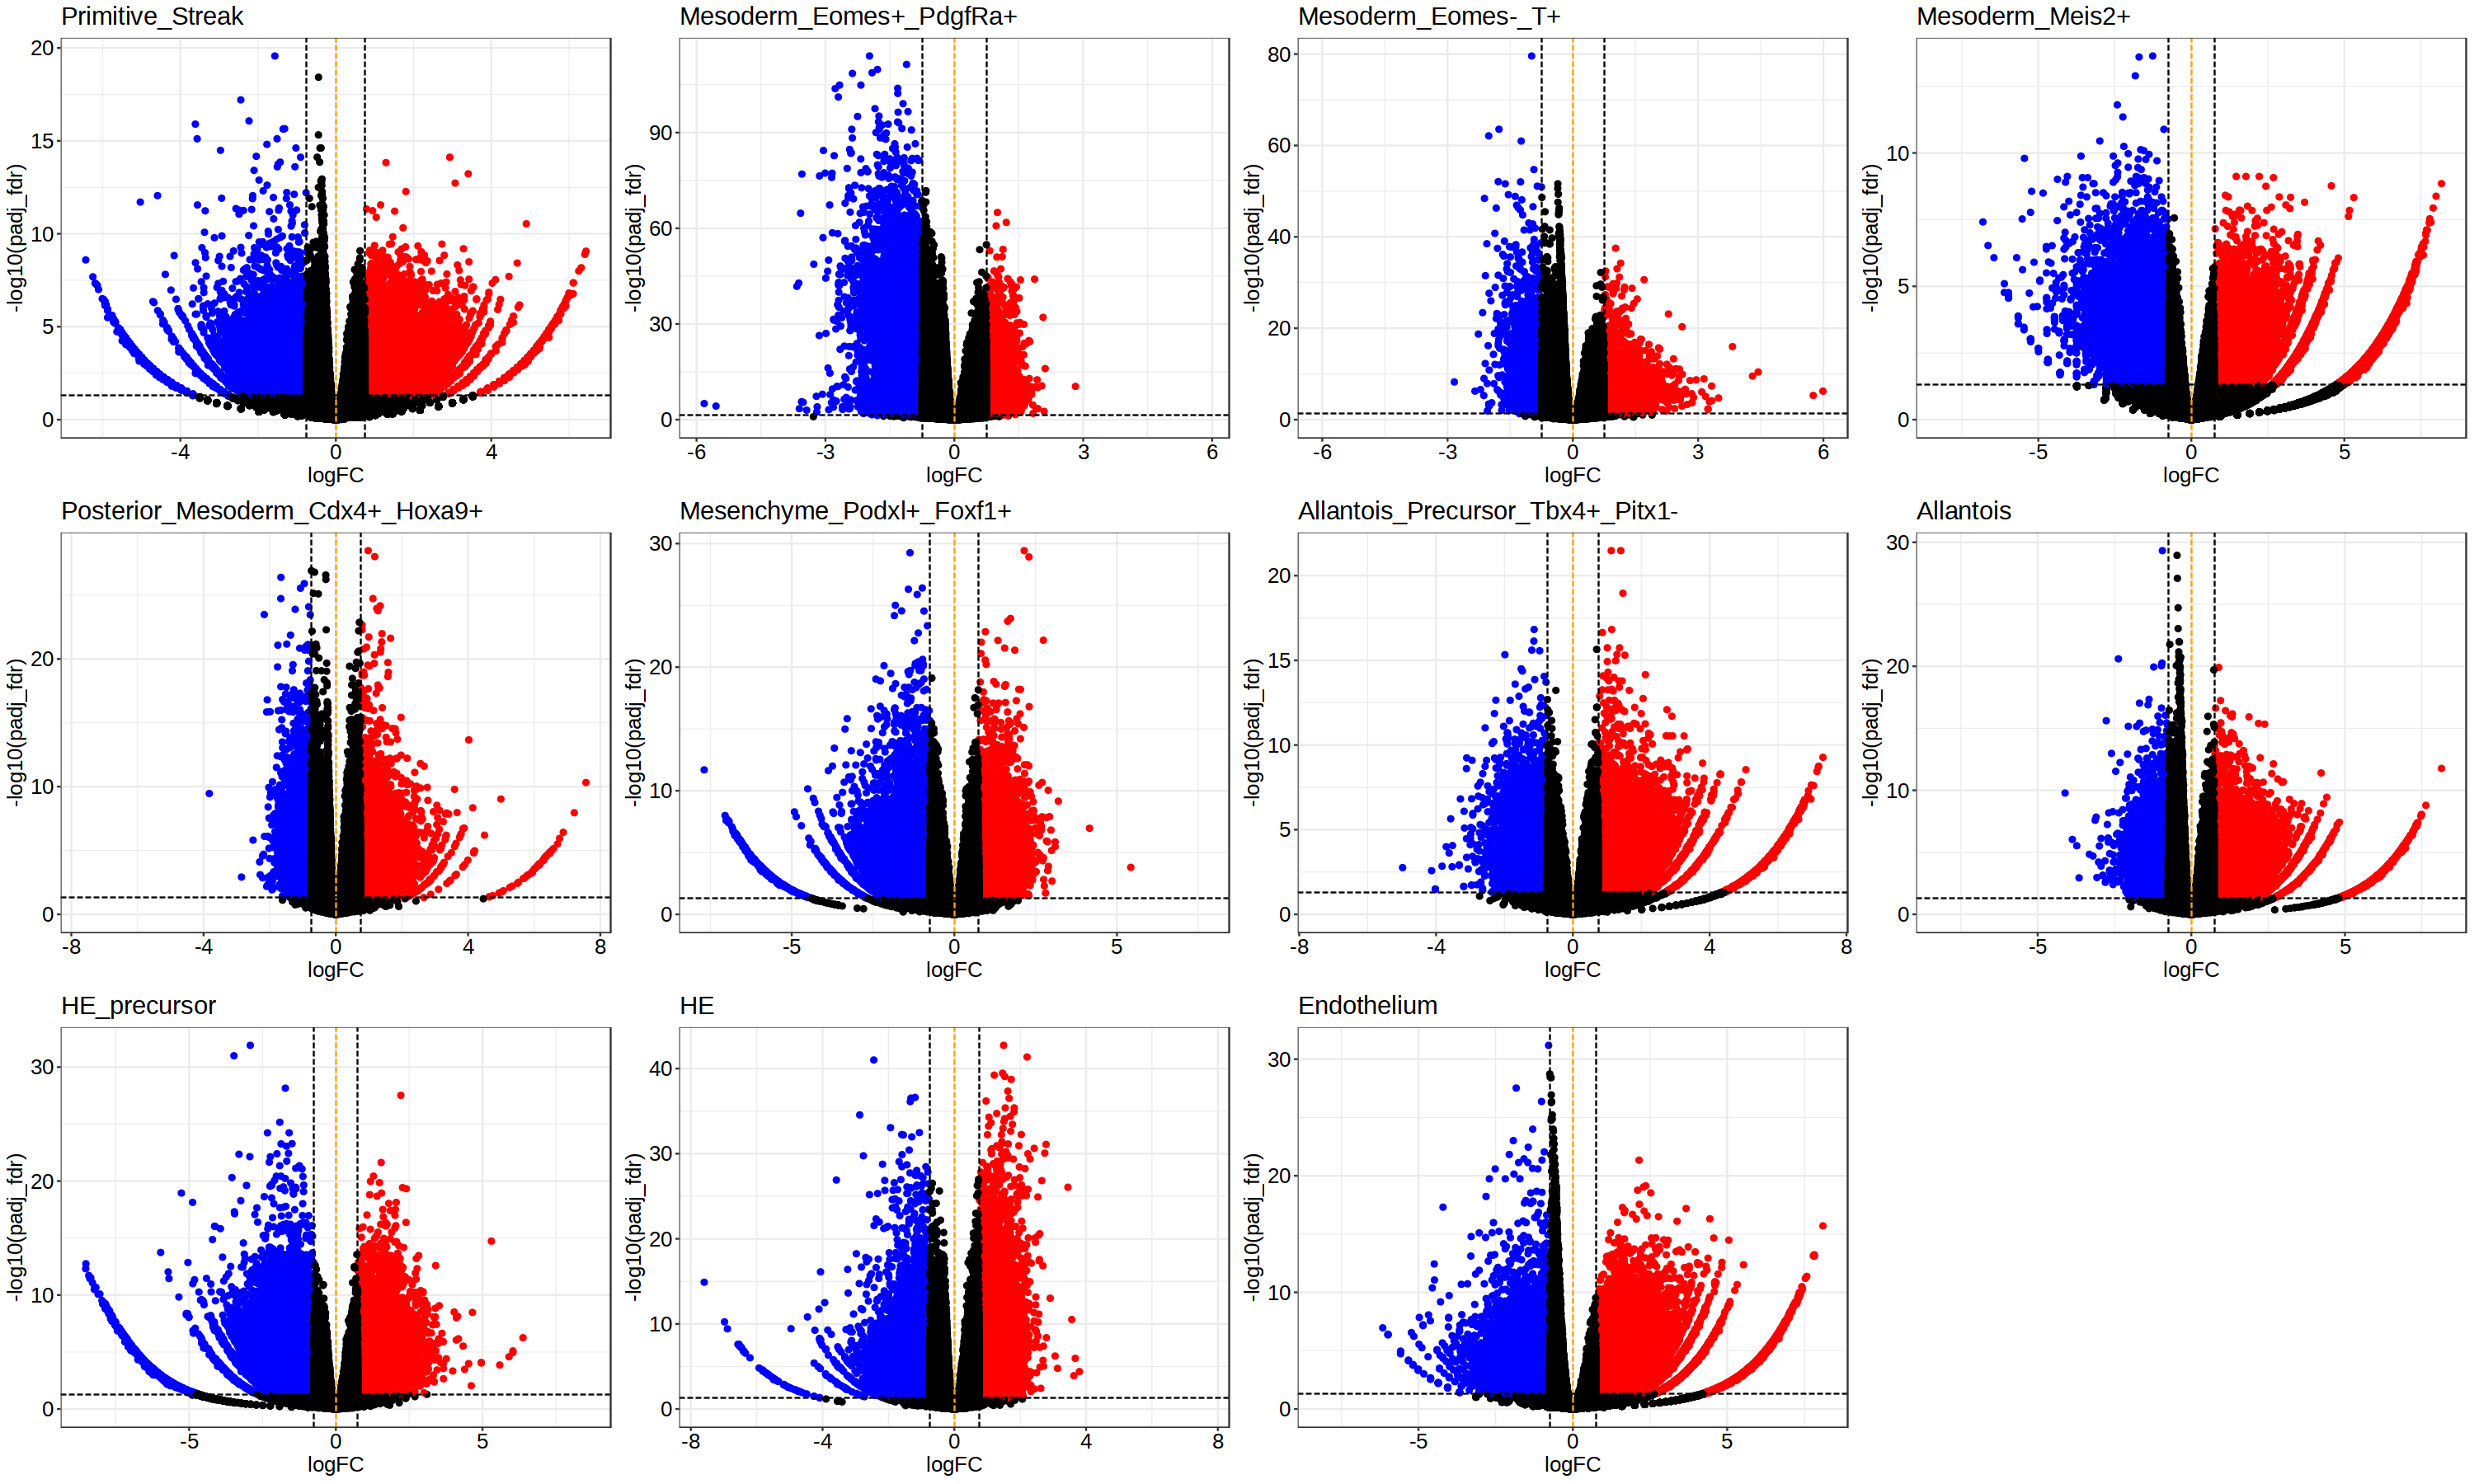

In [113]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

In [114]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(peakSet, DARs[celltype==i], by='feature', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [119]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_JASPAR2020",
    cutOff = "FDR <= 0.1 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-dc3e50f3d750-Date-2023-02-26_Time-18-22-57.log
If there is an issue, please report to github with logFile!



ERROR: Error in plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE): No enrichments found for your cutoff!


In [120]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-dc3e76db1757-Date-2023-02-26_Time-18-23-36.log
If there is an issue, please report to github with logFile!



ERROR: Error in plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE): No enrichments found for your cutoff!


# EdgeR single-cell

In [196]:
# Single cell DEG function

doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.25) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(counts(sce[,sce$genotype==opts$groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(counts(sce[,sce$genotype==opts$groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  sce$genotype <- factor(sce$genotype, levels=opts$groups)
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    

  design <- model.matrix(~sce$exp+sce$genotype) # might need to modify to only use this if celltype found in both experiments
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
     setnames(c("feature", 'idx',"logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

In [123]:
sample_metadata = meta[day!='D3']

In [194]:
# Single_cell
sce = atac.sce
sce$group = sample_metadata$genotype
opts$groups = c('wt', 'eomes_ko')
sce$exp = sample_metadata$exp
sce$group = factor(sce$group, levels = opts$groups)

In [197]:
de.results = mclapply(args$celltypes, function(x){     #unique(meta$celltype.mapped)
    # Only keep cell types with at least 20 cells in both KO and WT
    if(!TRUE %in% as.vector(as.data.frame(table(sample_metadata[celltypes_v1==x, genotype]))$Freq<20) & 
       length(unique(sample_metadata[celltypes_v1==x, genotype]))==2){
        message(x)
        sce_deg = sce[, sample_metadata$celltypes_v1==x]
            out <- doDiffExpr(sce_deg, opts$groups) %>%
              # Add sample statistics
              .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
              .[,c("groupA","groupB", "celltype"):=list(opts$groups[1],opts$groups[2],x)]%>%  
              # Calculate statistical significance
              .[, sig := (padj_fdr<=0.05 & abs(logFC)>=1)] %>%
              .[is.na(sig),sig:=FALSE] %>% 
              setorder(-sig, padj_fdr, na.last=T) %>%
              # Add celltype
                .[,celltype:=x]

            # Parse columns
            out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]
            return(out)
            } 
        }, mc.cores=12) %>% rbindlist()


In [198]:
DARs = de.results

In [199]:
fwrite(DARs, sprintf('%s/DARs_edgeR_sc', args$outdir))

In [12]:
DARs = fread( sprintf('%s/DARs_edgeR_sc', args$outdir))

In [13]:
sig = DARs[abs(logFC)>0.5 & padj_fdr< 0.05]

In [15]:
table(sig$celltype)


                       Allantois Allantois_Precursor_Tbx4+_Pitx1- 
                             218                              366 
                     Endothelium                               HE 
                            1656                              899 
                    HE_precursor         Mesenchyme_Podxl+_Foxf1+ 
                             867                              287 
              Mesoderm_Eomes-_T+          Mesoderm_Eomes+_PdgfRa+ 
                              13                              205 
                 Mesoderm_Meis2+  Posterior_Mesoderm_Cdx4+_Hoxa9+ 
                              39                               34 
                Primitive_Streak 
                              11 

In [8]:
DARs[celltype=='HE'][order(-logFC)]

feature,idx,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,celltype,sig
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>
chr1:82202717-82203317,6380,1.515,4.48e-56,1.61e-51,50.794,1595,378,wt,eomes_ko,HE,TRUE
chr15:59904660-59905260,3260,1.316,7.31e-43,6.57e-39,38.182,1595,378,wt,eomes_ko,HE,TRUE
chr6:11593792-11594392,478,1.302,4.50e-46,8.09e-42,41.092,1595,378,wt,eomes_ko,HE,TRUE
chr8:117403919-117404519,10318,1.291,1.52e-37,9.09e-34,33.041,1595,378,wt,eomes_ko,HE,TRUE
chr5:29211950-29212550,1499,1.278,4.66e-44,5.58e-40,39.253,1595,378,wt,eomes_ko,HE,TRUE
chr9:119477653-119478253,12664,1.253,1.96e-37,1.01e-33,32.998,1595,378,wt,eomes_ko,HE,TRUE
chr17:74119728-74120328,8597,1.226,5.92e-39,4.25e-35,34.371,1595,378,wt,eomes_ko,HE,TRUE
chr1:116044046-116044646,9435,1.213,1.37e-32,3.53e-29,28.453,1595,378,wt,eomes_ko,HE,TRUE
chr11:68135235-68135835,6785,1.206,2.97e-37,1.34e-33,32.874,1595,378,wt,eomes_ko,HE,TRUE


In [201]:
plots = mclapply(args$celltypes, function(x){
    tmp = DARs[celltype==x][!is.na(logFC)]
    p = volcano_plot(tmp, ntop=0, title=x, logFC_thr=0.25)
    return(p)
})

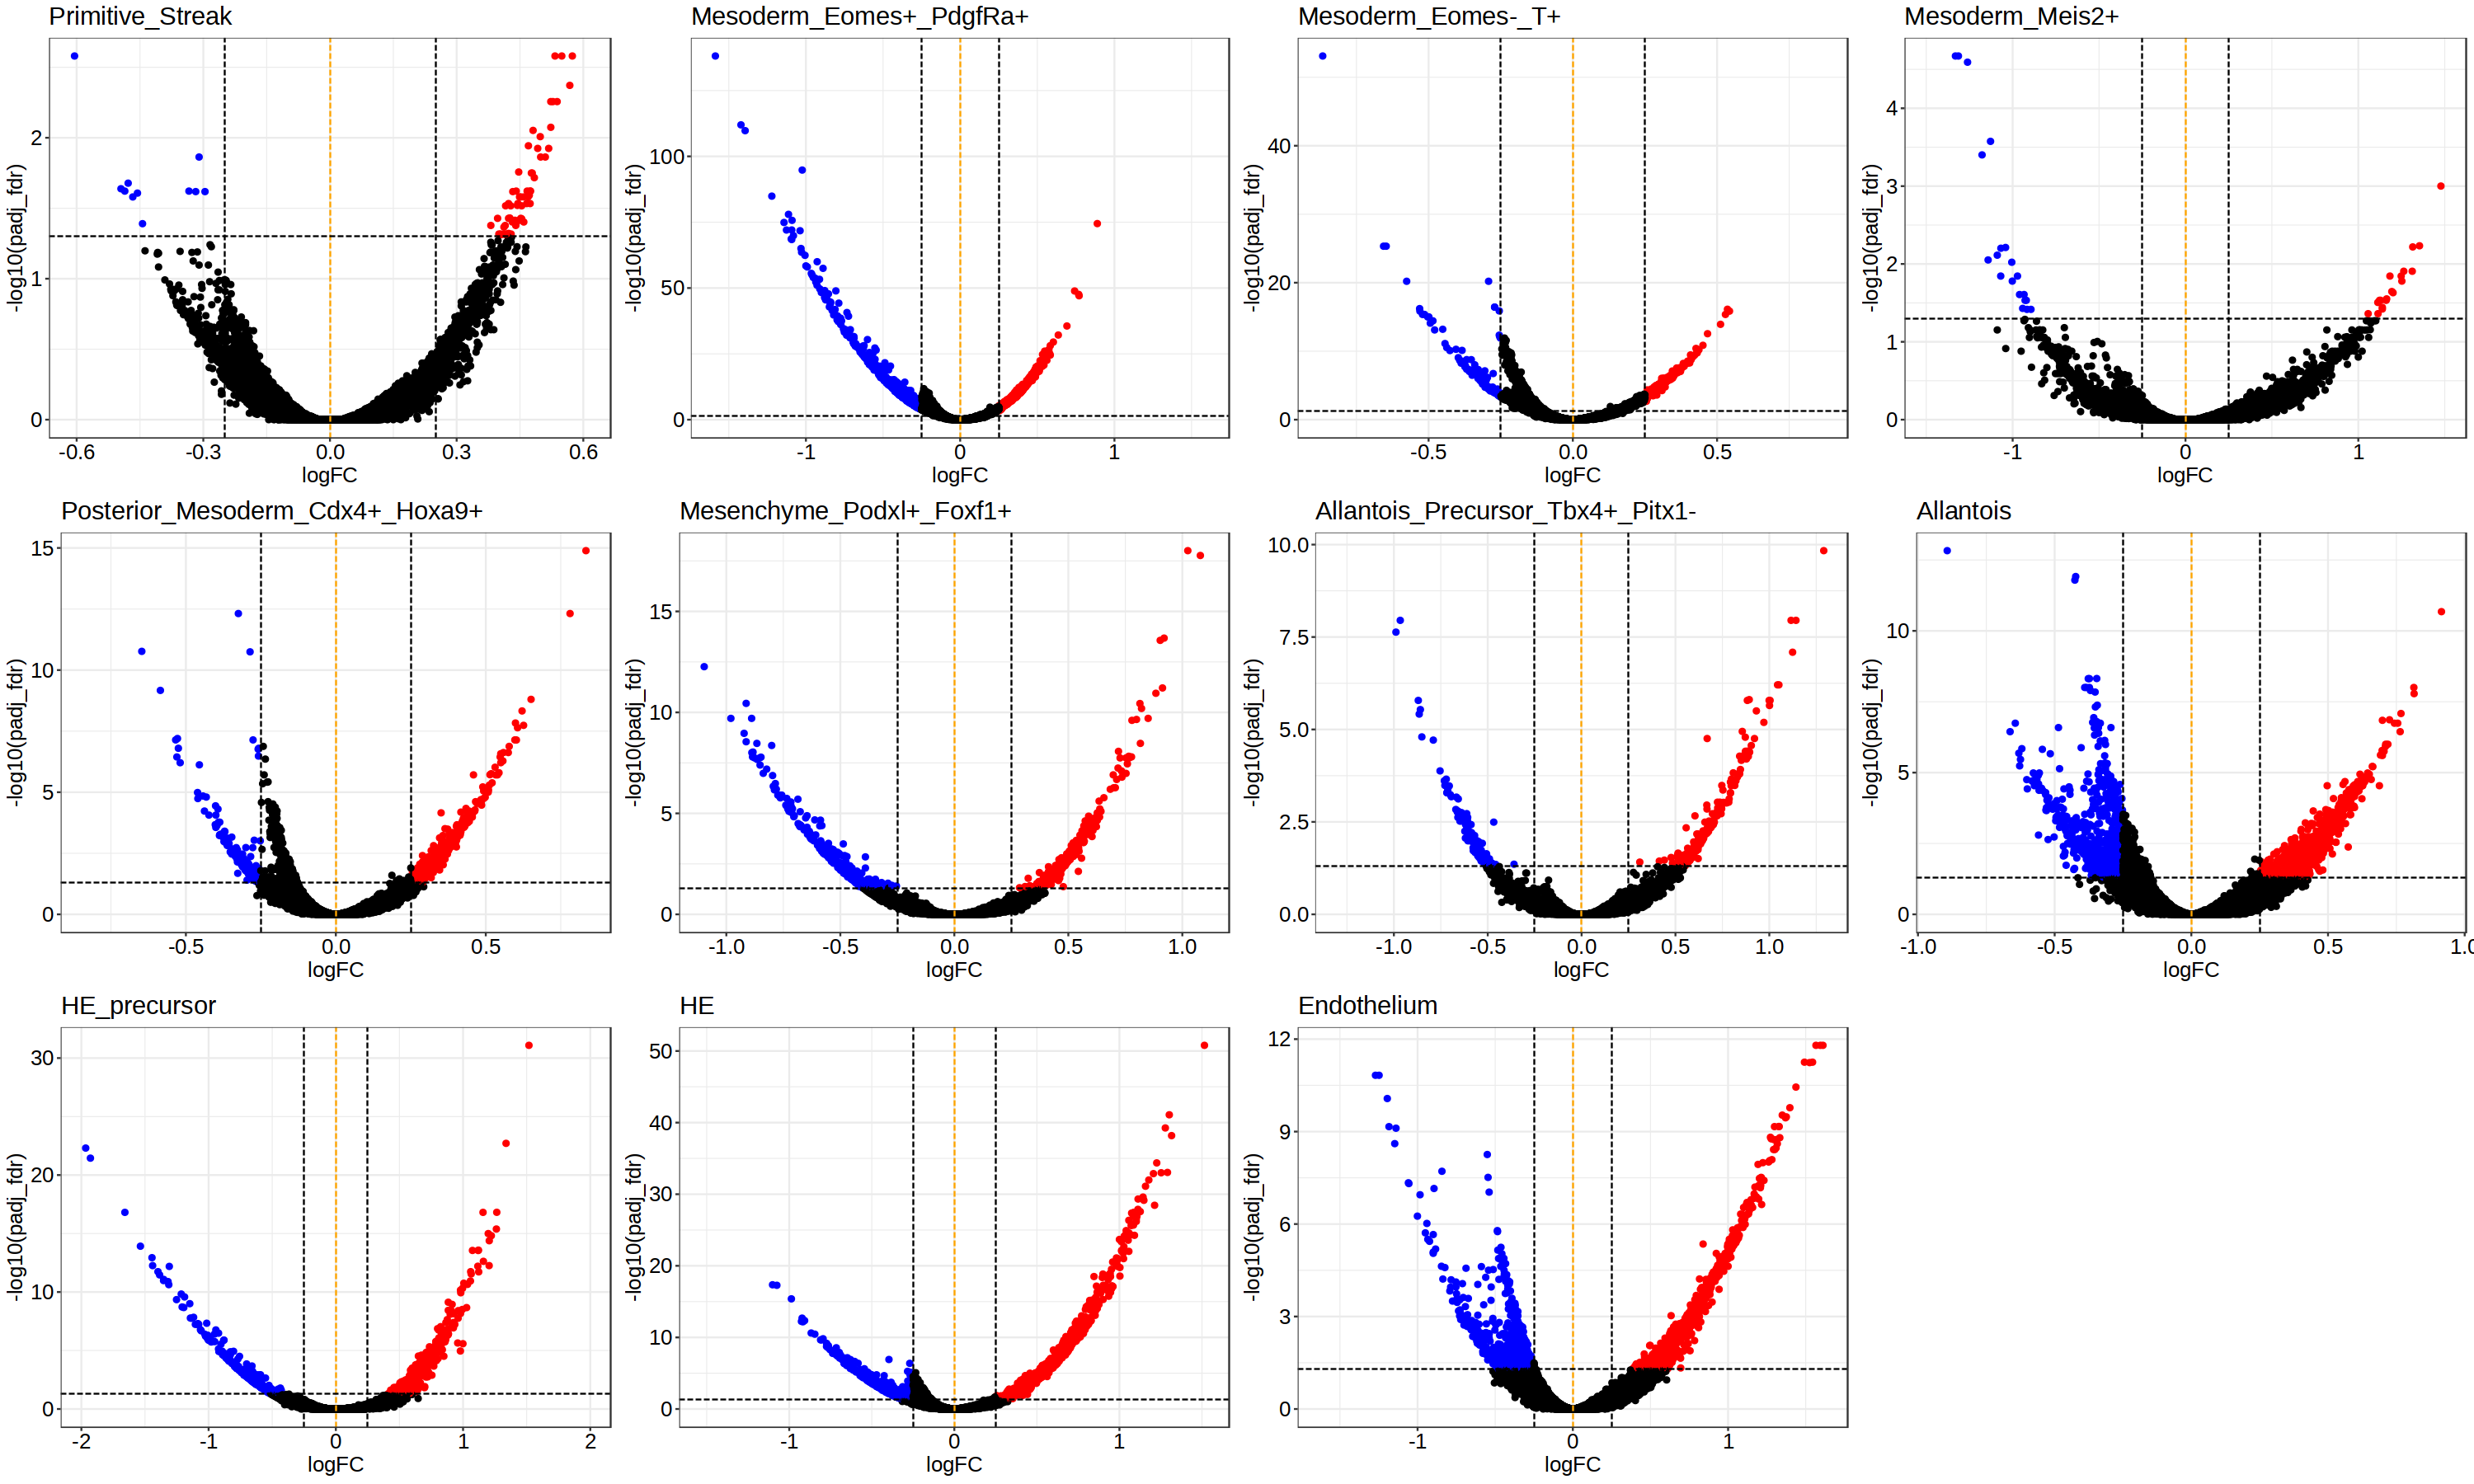

In [202]:
options(repr.plot.width=25, repr.plot.height=15)
ggarrange(plotlist=plots)

In [203]:
enrich_full = list()
for(i in unique(DARs$celltype)){
        tmp1 = merge(peakSet, DARs[celltype==i], by='feature', all.x=T) %>%
                        .[,c('Log2FC', 'FDR'):=list(ifelse(is.na(logFC), 0, logFC),
                                                    ifelse(is.na(padj_fdr), 1, padj_fdr))]
    tmp2 = markers
    tmp2@assays@data$Log2FC = data.frame('x'=tmp1$Log2FC)
    tmp2@assays@data$FDR = data.frame('x'=tmp1$FDR)
    colnames(tmp2) = i
    enrich_full[[i]] = tmp2
}
enrich_full = do.call('cbind', enrich_full)

In [215]:
enrich_full

class: SummarizedExperiment 
dim: 238993 11 
metadata(22): MatchInfo Params ... MatchInfo Params
assays(7): Log2FC Mean ... AUC MeanBGD
rownames(238993): 1 2 ... 238992 238993
rowData names(4): seqnames idx start end
colnames(11): Primitive_Streak Mesoderm_Eomes+_PdgfRa+ ... HE
  Endothelium
colData names(0):

In [ ]:
# Don't run because it crashes notebook! don't know why though?? maybe something to do with supress messages? it ran before.
# ct = 'HE'
# markers = suppressMessages(getMarkerFeatures(
#           ArchRProj = ArchRProject, 
#           useMatrix = "PeakMatrix",
#           groupBy = "celltype_genotype",
#           testMethod = "bimodial",
#           binarize=TRUE,
#           bias = c("TSSEnrichment", "log10(nFrags)"),
#           useGroups = paste0(ct, '-eomes_ko'),
#           bgdGroups = paste0(ct, '-wt'),
#           verbose= FALSE))

In [ ]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = markers,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.01 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

In [208]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.01 & Log2FC <= -0.5"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

ArchR logging to : ArchRLogs/ArchR-plotEnrichHeatmap-dc3e5710cced-Date-2023-02-26_Time-21-24-32.log
If there is an issue, please report to github with logFile!



ERROR: Error in plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE): No enrichments found for your cutoff!


In [ ]:
enrichMotifs <- suppressMessages(peakAnnoEnrichment(
    seMarker = enrich_full,
    ArchRProj = ArchRProject,
    peakAnnotation = "Motif_cisbp",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.25"
  ))

options(repr.plot.width=15, repr.plot.height=5)
plot_enr_heatmap(enrichMotifs, ntop = 50)

In [200]:
l

ERROR: Error in eval(expr, envir, enclos): object 'l' not found
